(demo:bayes-by-backprop)=

# Demo: Bayes by Backprop in PyTorch

The previous section derived the variational free energy and described *Bayes by
Backprop*. Here we implement it in `PyTorch`, and use it on a one-dimensional regression problem where we know
the right answer.

The point of the demo is to see the **two different uncertainties** that a
Bayesian neural network gives you, and to see that they behave differently:

- the **aleatoric** part is the noise in the data. It is irreducible: more data
  would pin it down more precisely but would not make it smaller.
- the **epistemic** part is our uncertainty about the weights. It is large where
  we have no data and shrinks where we have plenty.

See the general discussion on epistemic and aleatoric uncertainties in {ref}`sec:probabilistic-neural-network:epistemic-aleatoric`.

We will build a data set in which both are visible at a glance: the noise grows
from left to right, and there is a gap in the middle with no data at all.

## The data

We generate data with

$$
y = \sin(2x) + \varepsilon(x), \qquad
\varepsilon(x) \sim \mathcal{N}\left(0, \sigma_\mathrm{true}(x)^2\right),
$$

with a noise level that grows linearly across the interval. Both $\sin(2x)$ and
$\sigma_\mathrm{true}(x)$ are known to us, so at the end we can check what the
network learned against the truth. This is a luxury we never have in a real
problem, and exactly why a demo is worth exploring.

We sample $x$ uniformly from $[-3, 3]$ but leave $[0, 1]$ unsampled to study how our model performs for interpolation.

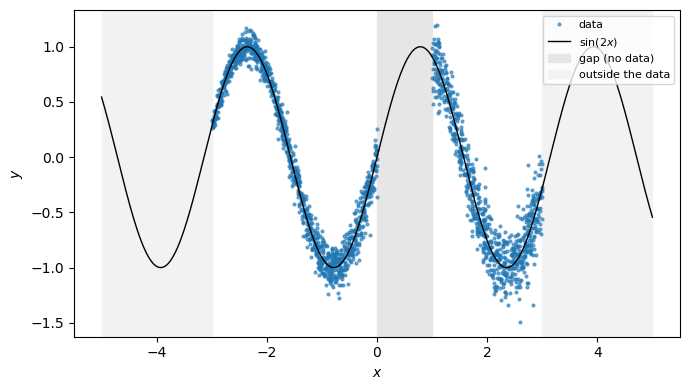

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1)
rng = np.random.default_rng(1)


def f_true(x):
    return np.sin(2.0 * x)


def sigma_true(x):
    """The noise level grows from left to right."""
    return 0.05 + 0.15 * (x + 3.0) / 6.0


# Sample x everywhere except the gap [0, 1]
n = 2000
x = rng.uniform(-3.0, 3.0, size=4 * n)
x = x[(x < 0.0) | (x > 1.0)][:n]
y = f_true(x) + rng.normal(0.0, sigma_true(x))

xt = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

xgrid = np.linspace(-5.0, 5.0, 500)          # note: wider than the data
xgrid_t = torch.tensor(xgrid, dtype=torch.float32).unsqueeze(1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, '.', ms=4, alpha=0.6, label='data')
ax.plot(xgrid, f_true(xgrid), 'k-', lw=1, label=r'$\sin(2x)$')
ax.axvspan(0.0, 1.0, color='0.9', label='gap (no data)')
ax.axvspan(-5.0, -3.0, color='0.95')
ax.axvspan(3.0, 5.0, color='0.95', label='outside the data')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()

## From variational inference to Bayes by Backprop

Variational inference (see {ref}`sec:bnns-in-practice:elbo`) is a *strategy* to address the hard Bayesian inference problem: replace the intractable
$p(\boldsymbol{w} \lvert \mathcal{D})$ by a tractable family of distributions
$q(\boldsymbol{w} \lvert \boldsymbol{\theta})$ and pick the member of that family that
maximises the ELBO, equation {eq}`eq:elbo`. It leaves two questions open:

- *Which family* $q$ should we use?
- *How* do we maximise the ELBO, which contains an expectation over $q$ that has
  no closed form?

*Bayes by Backprop* answers both so that training reduces to ordinary
backpropagation. Choice 1 answers the first question while choices 2 and 3
answer the second.

1. **The family is a diagonal Gaussian.** Every weight is independently normal
   with its own mean and width (the *mean-field* assumption). The KL term then
   becomes a sum of one-dimensional analytic expressions. The price is that a
   diagonal $q$ cannot capture the correlations of the true posterior, and
   mean-field methods tend to *underestimate* the posterior width in parameter
   space, although the predictive variance can still come out too large
   {cite}`Odgers2026`.
2. **The expectation over $q$ is estimated with one sample per gradient step.**
   A single draw of $\boldsymbol{w}$ gives a noisy but unbiased estimate; the
   noise averages out over many steps, as mini-batch noise does.
3. **The draw is made differentiable by the reparameterisation trick.** Writing
   $w = \mu + \sigma \epsilon$ with $\epsilon \sim \mathcal{N}(0, 1)$ moves the
   randomness into $\epsilon$, which carries no parameters, so gradients flow
   to $\mu$ and $\sigma$.

Together these turn "maximise the ELBO" into "call `.backward()`", hence the name.

Note that the optimiser adjusts $\boldsymbol{\theta} = (\mu, \rho)$, the parameters
of the *distribution over* the weights, not the weights themselves. The network
below has twice as many numbers to learn as its deterministic counterpart, and
none of them is a weight.


## A Bayesian linear layer

Every weight and bias gets a variational posterior
$q(w \lvert \theta) = \mathcal{N}(w; \mu, \sigma^2)$, parameterised by $\mu$ and
$\rho$ with $\sigma = \log(1 + e^{\rho})$ so that $\sigma$ stays positive. A
forward pass draws one sample using the reparameterisation trick,

$$
w = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I),
$$

so that gradients flow to $\mu$ and $\rho$ through a deterministic function of
$\epsilon$.

The layer also has to report its contribution to the KL divergence
$D_\mathrm{KL}(q \Vert p)$, equation {eq}`eq:KL`. For
two diagonal Gaussians this is analytic:

$$
D_\mathrm{KL} = \sum_j \left[ \log \frac{\sigma_p}{\sigma_j}
+ \frac{\sigma_j^2 + \mu_j^2}{2 \sigma_p^2} - \frac{1}{2} \right].
$$

We take the prior $p(w) = \mathcal{N}(0, \sigma_p^2)$ with
$\sigma_p^2 = 2 / n_\mathrm{in}$, which is the `relu` initialisation
distribution.

In [3]:
class BayesLinear(nn.Module):
    """Linear layer with q(w) = N(w; mu, sigma^2) and sigma = softplus(rho)."""

    def __init__(self, n_in, n_out):
        super().__init__()
        self.prior_sigma = (2.0 / n_in) ** 0.5
        self.w_mu = nn.Parameter(torch.randn(n_out, n_in) * self.prior_sigma)
        self.b_mu = nn.Parameter(torch.zeros(n_out))
        # softplus(-5) is about 0.007: start almost deterministic and let the
        # data widen the posterior. Starting wide often fails to train at all.
        self.w_rho = nn.Parameter(torch.full((n_out, n_in), -5.0))
        self.b_rho = nn.Parameter(torch.full((n_out,), -5.0))

    def forward(self, x):
        w = self.w_mu + F.softplus(self.w_rho) * torch.randn_like(self.w_rho)
        b = self.b_mu + F.softplus(self.b_rho) * torch.randn_like(self.b_rho)
        return F.linear(x, w, b)

    def kl(self):
        total = 0.0
        for mu, rho in ((self.w_mu, self.w_rho), (self.b_mu, self.b_rho)):
            sigma = F.softplus(rho)
            total = total + (torch.log(self.prior_sigma / sigma)
                             + (sigma ** 2 + mu ** 2) / (2 * self.prior_sigma ** 2)
                             - 0.5).sum()
        return total

## The network

The architecture is chosen empirically. Two hidden layers of width 16 (about 340
weights and biases, each with a mean and a width to learn) is enough to follow
$\sin(2x)$ and the growing noise level. Smaller networks underfit the mean near the
edges, and the residual then lands in the aleatoric term. Much larger networks do
not help either: the KL term penalises every parameter that deviates from the prior,
and the fit degrades with too many parameters such that the
epistemic width becomes large everywhere. The output layer produces **two** numbers
rather than one: the mean $\mu(x)$ and the log-variance $\log v(x)$ of the
predictive distribution at that $x$. Letting the network output the width is
what allows the aleatoric term to depend on the input, which it must here, since
$\sigma_\mathrm{true}$ grows with $x$.

Clamping the log-variance is used to avoid sending it to $-\infty$ due to a single unlucky batch
early in training, which would cause the run to never recover.

In [4]:
class BayesMLP(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.h1 = BayesLinear(1, width)
        self.h2 = BayesLinear(width, width)
        self.out = BayesLinear(width, 2)      # mean and log-variance

    def forward(self, x):
        x = torch.tanh(self.h1(x))
        x = torch.tanh(self.h2(x))
        o = self.out(x)
        return o[:, 0:1], o[:, 1:2].clamp(-10.0, 2.0)

    def kl(self):
        return self.h1.kl() + self.h2.kl() + self.out.kl()

## The cost

We minimise the variational free energy $\mathcal{F} = -J_\mathrm{ELBO}$. Per
data point,

$$
\frac{\mathcal{F}}{N} = \mathbb{E}_{q}\left[-\log p(y \lvert x, w)\right]
+ \frac{D_\mathrm{KL}(q \Vert p)}{N},
$$

where the expectation is estimated with a single weight sample per step --- one
sample is noisy but unbiased, and the noise averages out over many steps.

Two things to be careful about. The KL term is divided by the size of the
**data set**, not the size of the mini-batch: it is a single penalty shared over
all $N$ points, and getting this wrong reweights prior against likelihood by the
ratio of the two. And with a predicted variance the likelihood is Gaussian, so

$$
-\log p(y \lvert x, w) = \tfrac{1}{2}\left[ \log v(x)
+ \frac{(y - \mu(x))^2}{v(x)} \right] + \text{const},
$$

which reduces to the familiar squared error only when $v$ is held fixed.

In [5]:
def gaussian_nll(y, mean, log_var):
    return 0.5 * (log_var + (y - mean) ** 2 / log_var.exp()).mean()


net = BayesMLP()
opt = torch.optim.Adam(net.parameters(), lr=0.01)

N = len(xt)
for step in range(8000):
    mean, log_var = net(xt)
    loss = gaussian_nll(yt, mean, log_var) + net.kl() / N     # F / N
    opt.zero_grad(); loss.backward(); opt.step()
    if (step + 1) % 2000 == 0:
        print(f'step {step + 1:5d}   F/N = {loss.item():8.4f}   '
              f'KL/N = {(net.kl() / N).item():7.4f}')

step  2000   F/N =  -1.0919   KL/N =  0.3515
step  4000   F/N =  -1.1637   KL/N =  0.3304
step  6000   F/N =  -1.0004   KL/N =  0.3150
step  8000   F/N =  -1.2703   KL/N =  0.3064


## The predictive distribution

The quantity we actually want is

$$
p(y \lvert x, \mathcal{D}) = \int d w \, p(y \lvert x, w) \, q(w \lvert \theta^*),
$$

which we estimate by drawing $S$ weight samples. Each sample $w_s$ gives a mean
$\mu_s(x)$ and a variance $v_s(x)$, and the **law of total variance** splits the
result into the two pieces exactly:

$$
\underbrace{\mathrm{Var}\left[y \lvert x, \mathcal{D}\right]}_{\text{total}}
= \underbrace{\mathbb{E}_{q}\left[v_w(x)\right]}_{\text{aleatoric}}
+ \underbrace{\mathrm{Var}_{q}\left[\mu_w(x)\right]}_{\text{epistemic}} .
$$

In words: average the *variances* to get the aleatoric part, and take the
variance of the *means* to get the epistemic part. Both come out of the same $S$
forward passes.

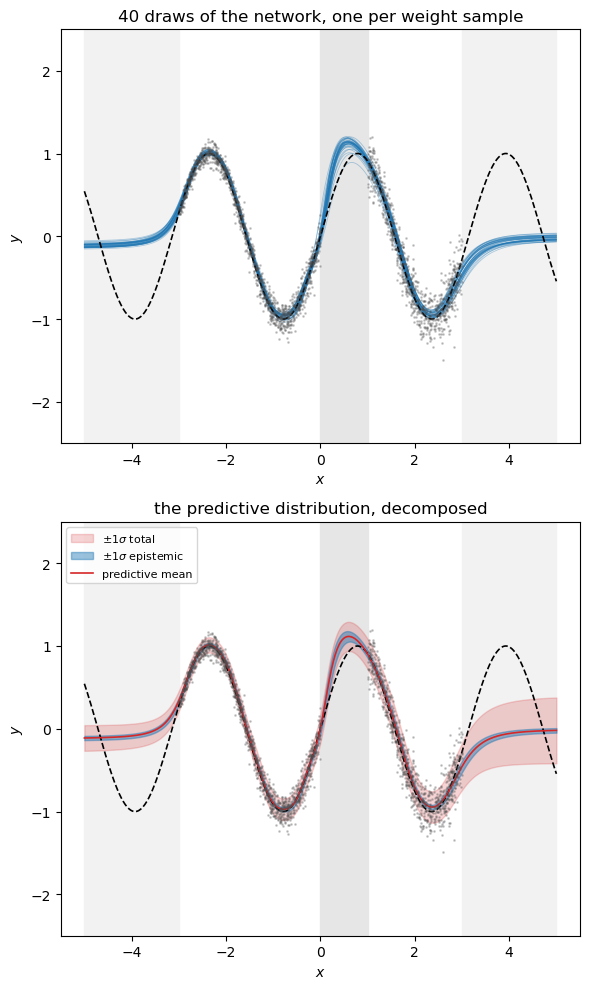

In [8]:
@torch.no_grad()
def predictive(net, x, n_samples=200):
    """Predictive mean, epistemic std and aleatoric std."""
    means, variances = [], []
    for _ in range(n_samples):
        m, lv = net(x)
        means.append(m); variances.append(lv.exp())
    means = torch.stack(means); variances = torch.stack(variances)
    return (means.mean(0).squeeze(),            # predictive mean
            means.std(0).squeeze(),             # epistemic:  std of the means
            variances.mean(0).squeeze().sqrt())  # aleatoric: mean of the variances


mu, epi, ale = predictive(net, xgrid_t)
mu, epi, ale = mu.numpy(), epi.numpy(), ale.numpy()
tot = np.sqrt(epi ** 2 + ale ** 2)

fig, axs = plt.subplots(2, 1, figsize=(6, 10))#, sharey=True, sharex=True)

# (a) draws of the function itself: one curve per weight sample
with torch.no_grad():
    for _ in range(40):
        m, _ = net(xgrid_t)
        axs[0].plot(xgrid, m.squeeze().numpy(), 'C0-', lw=0.6, alpha=0.35)
axs[0].plot(xgrid, f_true(xgrid), 'k--', lw=1.2, label=r'true $\sin(2x)$')
axs[0].plot(x, y, '.', ms=2, alpha=0.25, color='0.3')
axs[0].set_title('40 draws of the network, one per weight sample')

# (b) the same information as a band, split into its two parts
axs[1].fill_between(xgrid, mu - tot, mu + tot, color='C3', alpha=0.20,
                    label=r'$\pm 1\sigma$ total')
axs[1].fill_between(xgrid, mu - epi, mu + epi, color='C0', alpha=0.45,
                    label=r'$\pm 1\sigma$ epistemic')
axs[1].plot(xgrid, f_true(xgrid), 'k--', lw=1.2)
axs[1].plot(xgrid, mu, 'C3-', lw=1.2, label='predictive mean')
axs[1].plot(x, y, '.', ms=2, alpha=0.25, color='0.3')
axs[1].set_title('the predictive distribution, decomposed')
axs[1].legend(loc='upper left', fontsize=8)
axs[1].set_ylabel('$y$'); axs[1].set_ylim(-2.5, 2.5)

for a in axs:
    a.axvspan(0.0, 1.0, color='0.9', zorder=0)
    a.axvspan(-5.0, -3.0, color='0.95', zorder=0)
    a.axvspan(3.0, 5.0, color='0.95', zorder=0)
    a.set_xlabel('$x$')
axs[0].set_ylabel('$y$'); axs[0].set_ylim(-2.5, 2.5)
fig.tight_layout()

Three things to look at, one of which is a warning.

1. **Inside the data** the individual draws lie almost on top of each other and
   the blue epistemic band is thin: many points constrain the weights there. The
   red total band is wider due to the noise. Note
   that it widens towards the right, following $\sigma_\mathrm{true}$.
2. **In the gap** $[0, 1]$ the draws visibly fan out and the epistemic band
   roughly doubles. Nothing pinned the weights down there, so different draws of
   $\boldsymbol{w}$ disagree about what the function does in between. This is
   the honest statement "I have not been told", and it is the thing an ordinary
   network trained on the squared error cannot give you: that would be a single
   curve, equally confident in the gap as in the middle of the data.
3. **Outside** $[-3, 3]$, however, the draws *converge* again and the epistemic
   band gets narrower, not wider. This is not the network becoming certain; it
   is the `tanh` units saturating. A unit saturates once $|wx+b| \gg 1$, which
   for a scalar input is unavoidable at large $|x|$, so every sampled network
   outputs a near-constant there and the constants differ little. Swap `tanh`
   for `relu` and the extrapolation becomes linear instead of flat, with a
   different but equally arbitrary confidence.

The third point is particularly important. *How a network behaves far from its
training data is a property of the architecture, not of the Bayesian treatment*.
Compare with a Gaussian process ({ref}`sec:GPIntuition`), where the posterior far
from the data reverts to the prior: the mean goes to zero and the variance to the
kernel amplitude, both dictated by the kernel we chose. A Bayesian neural network
does the same, except that its prior over functions is defined implicitly by the
architecture and the weight prior, and is harder to read off. Epistemic
uncertainty beyond the data is therefore only as trustworthy as that prior, and
mean-field variational inference narrows it further {cite}`Odgers2026`. It remains a useful warning
about gaps *between* data.


## Did it learn the right noise?

Because we generated the data, we can check the aleatoric term against the truth.
This is the part that would be invisible in a real problem.

where there is data: mean |learned - true| noise = 0.022
epistemic sigma, inside the data: 0.038
epistemic sigma, in the gap:      0.085


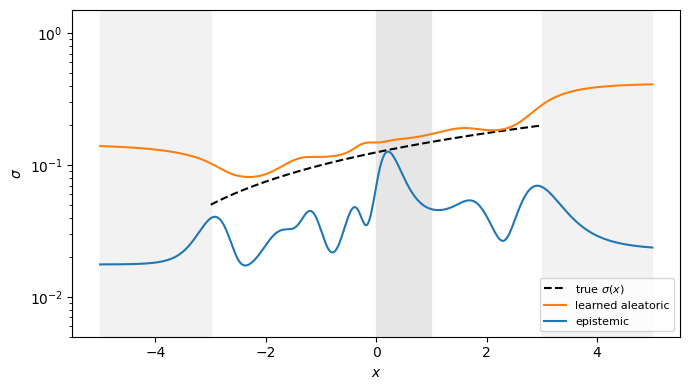

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
# sigma_true is only defined on the interval the data were drawn from
data_range = (xgrid >= -3.0) & (xgrid <= 3.0)
ax.plot(xgrid[data_range], sigma_true(xgrid[data_range]), 'k--', lw=1.5,
        label=r'true $\sigma(x)$')
ax.plot(xgrid, ale, 'C1-', label='learned aleatoric')
ax.plot(xgrid, epi, 'C0-', label='epistemic')
ax.axvspan(0.0, 1.0, color='0.9', zorder=0)
ax.axvspan(-5.0, -3.0, color='0.95', zorder=0)
ax.axvspan(3.0, 5.0, color='0.95', zorder=0)
ax.set_xlabel('$x$'); ax.set_ylabel(r'$\sigma$')
ax.set_yscale('log'); ax.set_ylim(5e-3, 1.5)
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()

inside = (xgrid > -3.0) & (xgrid < 3.0) & ~((xgrid > 0.0) & (xgrid < 1.0))
print(f'where there is data: mean |learned - true| noise = '
      f'{np.abs(ale[inside] - sigma_true(xgrid[inside])).mean():.3f}')
print(f'epistemic sigma, inside the data: {epi[inside].mean():.3f}')
print(f'epistemic sigma, in the gap:      '
      f'{epi[(xgrid > 0.2) & (xgrid < 0.8)].mean():.3f}')

Over most of the interval the learned aleatoric term tracks
$\sigma_\mathrm{true}(x)$ and reproduces its growth from left to right: the
network worked out not just *that* the data are noisy but *where* they are
noisier, which is the whole reason for letting the width depend on the input.

Where it does not track is also instructive. Towards the left edge, where the true
noise is smallest, the learned width sits well above it. The noise model is not at fault. The fit is slightly worse there, and a Gaussian likelihood can only account for a residual it cannot remove by calling it noise. **A learned aleatoric term absorbs model discrepancy.** 

Notice which term does what. Across the gap it is the **epistemic** curve that
rises; the aleatoric one simply interpolates, because a predicted noise level is
a fitted function like any other and has no obligation to behave sensibly where
it has seen nothing. Whenever you report a single combined error bar you lose
this distinction, and with it the ability to say whether more data would
help.

Finally, outside the data range the epistemic curve falls rather than rises, for
the reason discussed above: `tanh` saturation, not certainty.

## What to take away

- A Bayesian neural network by variational inference is a small change to an
  ordinary one: weights carry a distribution, the forward pass samples from it,
  and the cost gains a KL term.
- The predictive spread separates cleanly, by the law of total variance, into a
  part that reflects noise in the data and a part that reflects ignorance about
  the weights. They behave differently and should be reported separately.
- Mean-field variational inference is known to *underestimate* posterior width:
  it assumes the weights are independent, which they are not. Treat the
  epistemic band as a useful warning rather than a calibrated interval, and
  check calibration whenever you can.
